<a href="https://colab.research.google.com/github/anletobe/inventario-ia-arbol-decision/blob/main/Actividad_Creaci%C3%B3n_de_un_modelo_de_inteligencia_artificial_avanzada_Andres_Torres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# ACTIVIDAD - CREACIÓN DE UN MODELO DE INTELIGENCIA ARTIFICIAL AVANZADA

# Modelo de Inteligencia Artificial para la Clasificación del Estado del Inventario mediante un Árbol de Decisión
#
# ==========================================================

# ==========================================================
# PASO 1. INSTALAR LIBRERÍAS NECESARIAS
# ==========================================================

# KaggleHub permite descargar datasets directamente desde Kaggle.
!pip install -q kagglehub

In [ ]:
# ==========================================================
# PASO 2. IMPORTAR LIBRERÍAS
# ==========================================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Manejo de archivos y rutas
import os

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Librería para descargar datasets desde Kaggle
import kagglehub

print("Todas las librerías fueron importadas correctamente.")

Todas las librerías fueron importadas correctamente.


In [ ]:
# ==========================================================
# PASO 3. DESCARGAR EL DATASET DESDE KAGGLE
# ==========================================================

# Descargar el dataset del repositorio de Kaggle.
dataset_path = kagglehub.dataset_download(
    "burtonmx/inventarioproductosbodega"
)

print("Dataset descargado correctamente.")
print(dataset_path)

# Mostrar los archivos descargados
print("\nArchivos encontrados:\n")

for archivo in os.listdir(dataset_path):
    print("-", archivo)

Using Colab cache for faster access to the 'inventarioproductosbodega' dataset.
Dataset descargado correctamente.
/kaggle/input/inventarioproductosbodega

Archivos encontrados:

- InventarioEstadisticoProductosBodega.csv


In [ ]:
# ==========================================================
# PASO 4. CARGAR EL DATASET
# ==========================================================

# Construir la ruta completa del archivo CSV
ruta_csv = os.path.join(
    dataset_path,
    "InventarioEstadisticoProductosBodega.csv"
)

# Cargar el archivo
# Se utiliza:
# - encoding="ISO-8859-1" porque el archivo contiene caracteres especiales.
# - sep=";" porque los datos están separados por punto y coma.
# - skiprows=1 porque la primera línea está vacía.
df = pd.read_csv(
    ruta_csv,
    encoding="ISO-8859-1",
    sep=";",
    skiprows=1
)

print("✅ Dataset cargado correctamente.")

✅ Dataset cargado correctamente.


In [ ]:
# ==========================================================
# PASO 5. PRIMERA VISTA DEL DATASET
# ==========================================================

print("\nDimensiones del dataset")
print(f"Filas    : {df.shape[0]}")
print(f"Columnas : {df.shape[1]}")

print("\nPrimeros registros del dataset")

display(df.head())


Dimensiones del dataset
Filas    : 200
Columnas : 17

Primeros registros del dataset


,ID,Código,Nombre Producto,Categoría,Subcategoría,Proveedor,Bodega,Estado,Condición,Calificación,Precio (USD),Costo (USD),Descuento (%),Peso (kg),Stock,Ventas (mes),Días en Inventario
0,1001,ROP-0001,Toalla Microfibra,Ropa,Camisas,ProveedorA,Bodega Sur,Agotado,Excelente,?,"210,05","94,28","12,7","2,219",52,279,288
1,1002,HOG-0002,Figura Acción,Hogar,Limpieza,ProveedorC,Bodega Centro,Agotado,Buena,????,"189,32","114,77","4,8","18,982",414,3,173
2,1003,ROP-0003,Medias Compresión,Ropa,Camisas,ProveedorA,Bodega Este,Disponible,Regular,?????,"84,47","58,84","21,9","20,188",309,135,322
3,1004,JUG-0004,Leche Entera,Juguetes,Electrónicos,ProveedorD,Bodega Centro,En tránsito,Regular,?,"599,62","249,47","25,7","24,631",116,148,84
4,1005,JUG-0005,Atún Lata,Juguetes,Construcción,ProveedorB,Bodega Este,En tránsito,Regular,??,"570,47","368,32","5,1","15,248",349,36,328


In [ ]:
# ==========================================================
# PASO 6. EXPLORAR LAS COLUMNAS
# ==========================================================

print("Columnas del dataset:\n")

for columna in df.columns:
    print("-", columna)

Columnas del dataset:

- ID
- Código
- Nombre Producto
- Categoría
- Subcategoría
- Proveedor
- Bodega
- Estado
- Condición
- Calificación
- Precio (USD)
- Costo (USD)
- Descuento (%)
- Peso (kg)
- Stock
- Ventas (mes)
- Días en Inventario


In [ ]:
# ==========================================================
# PASO 7. INFORMACIÓN GENERAL DEL DATASET
# ==========================================================

print("Información general del dataset:\n")

df.info()

Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  200 non-null    int64 
 1   Código              200 non-null    object
 2   Nombre Producto     200 non-null    object
 3   Categoría           200 non-null    object
 4   Subcategoría        200 non-null    object
 5   Proveedor           200 non-null    object
 6   Bodega              200 non-null    object
 7   Estado              200 non-null    object
 8   Condición           200 non-null    object
 9   Calificación        200 non-null    object
 10  Precio (USD)        200 non-null    object
 11  Costo (USD)         200 non-null    object
 12  Descuento (%)       200 non-null    object
 13  Peso (kg)           200 non-null    object
 14  Stock               200 non-null    int64 
 15  Ventas (mes)        200 non-null    int6

In [ ]:
# ==========================================================
# PASO 8. ESTADÍSTICAS DESCRIPTIVAS
# ==========================================================

print("\nEstadísticas descriptivas:\n")

display(df.describe())


Estadísticas descriptivas:



,ID,Stock,Ventas (mes),Días en Inventario
count,200.00,200.00,200.00,200.00
mean,1100.50,267.50,156.22,186.11
std,57.88,142.85,84.14,102.03
min,1001.00,4.00,0.00,2.00
25%,1050.75,150.00,84.00,98.75
50%,1100.50,280.00,163.00,184.00
75%,1150.25,390.25,227.00,276.25
max,1200.00,500.00,299.00,364.00


In [ ]:
# ==========================================================
# PASO 9. VERIFICAR VALORES NULOS Y DUPLICADOS
# ==========================================================

print("Valores nulos por columna:\n")

display(df.isnull().sum())

print("\nCantidad de registros duplicados:")

print(df.duplicated().sum())

Valores nulos por columna:



,0
ID,0
Código,0
Nombre Producto,0
Categoría,0
Subcategoría,0
Proveedor,0
Bodega,0
Estado,0
Condición,0
Calificación,0



Cantidad de registros duplicados:
0


In [ ]:
# ==========================================================
# PASO 10. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================================

# En esta etapa se exploran los datos mediante gráficas.
# El objetivo es comprender cómo están distribuidas las
# variables del conjunto de datos antes de entrenar
# el modelo de Árbol de Decisión.

print("="*60)
print("ANÁLISIS EXPLORATORIO DE DATOS")
print("="*60)

ANÁLISIS EXPLORATORIO DE DATOS


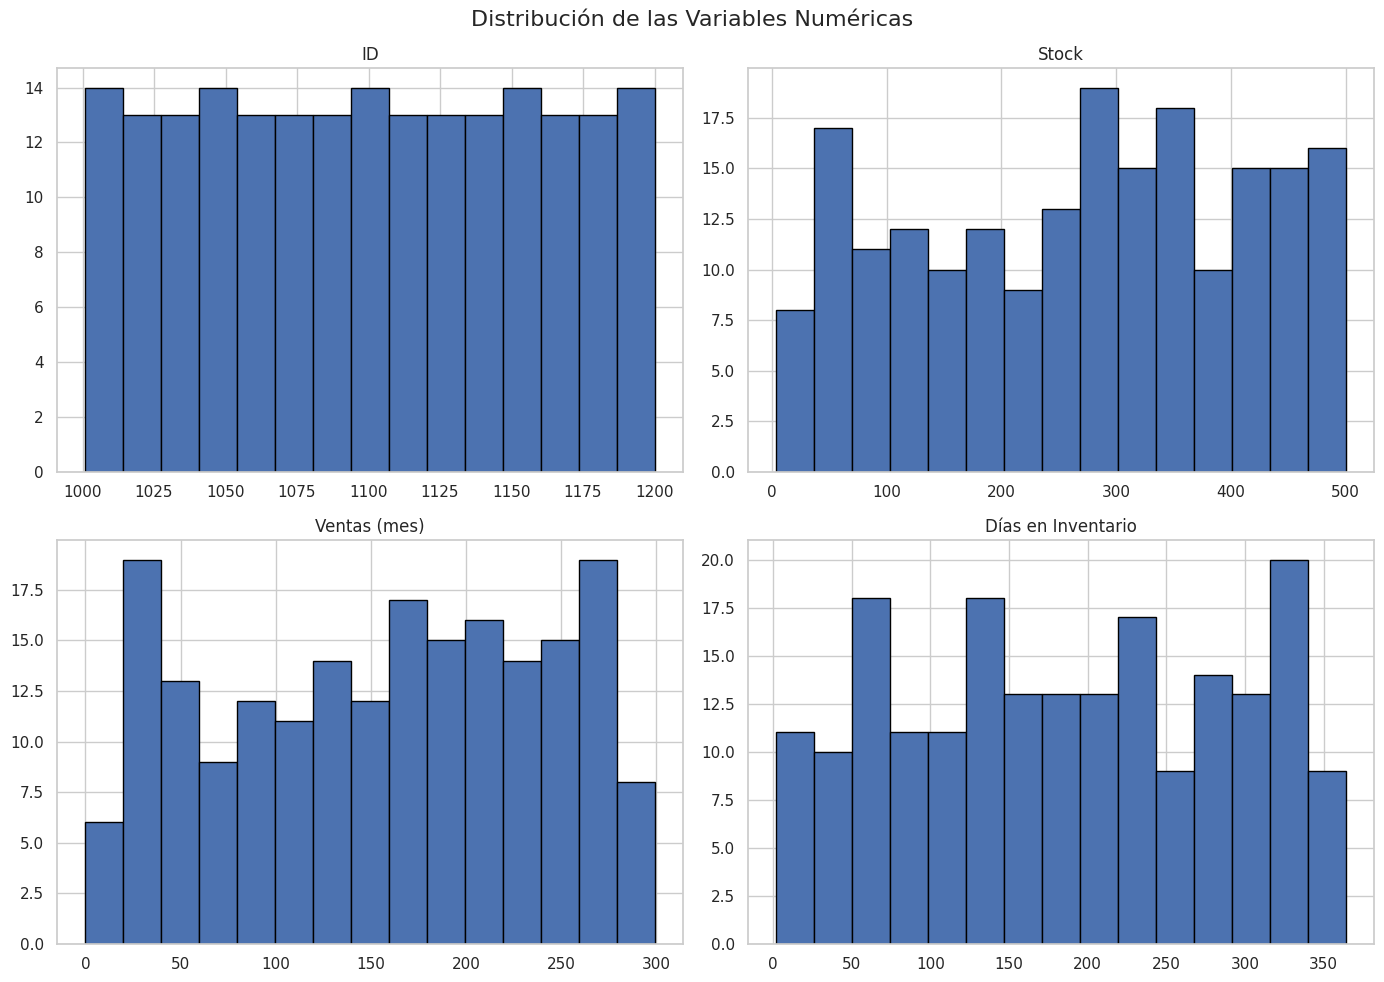

In [ ]:
# ==========================================================
# PASO 10.1 DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
# ==========================================================

# Seleccionar únicamente las columnas numéricas
variables_numericas = df.select_dtypes(include=["int64", "float64"]).columns

# Crear histogramas para todas las variables numéricas
df[variables_numericas].hist(
    figsize=(14,10),      # Tamaño de la figura
    bins=15,              # Número de intervalos
    edgecolor="black"     # Color del borde de cada barra
)

# Agregar un título general
plt.suptitle(
    "Distribución de las Variables Numéricas",
    fontsize=16
)

# Ajustar automáticamente los espacios entre gráficas
plt.tight_layout()

# Mostrar la figura
plt.show()

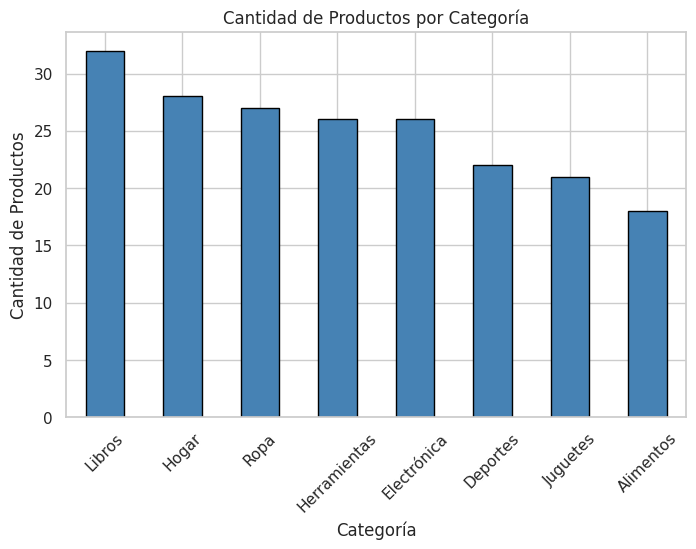

In [ ]:
# ==========================================================
# PASO 10.2 PRODUCTOS POR CATEGORÍA
# ==========================================================

# Crear una nueva figura
plt.figure(figsize=(8,5))

# Contar la cantidad de productos existentes
# en cada categoría y representarlos mediante
# un gráfico de barras.
df["Categoría"].value_counts().plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

# Agregar título y etiquetas
plt.title("Cantidad de Productos por Categoría")

plt.xlabel("Categoría")

plt.ylabel("Cantidad de Productos")

# Rotar las etiquetas para mejorar la lectura
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.show()

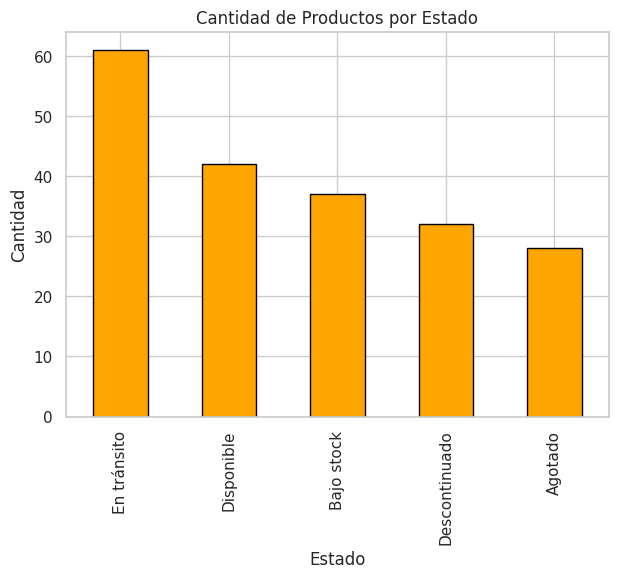

In [ ]:
# ==========================================================
# PASO 10.3 PRODUCTOS POR ESTADO
# ==========================================================

# Crear una nueva figura
plt.figure(figsize=(7,5))

# Contar la cantidad de productos según su estado
df["Estado"].value_counts().plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

# Agregar título y etiquetas
plt.title("Cantidad de Productos por Estado")

plt.xlabel("Estado")

plt.ylabel("Cantidad")

# Mostrar el gráfico
plt.show()

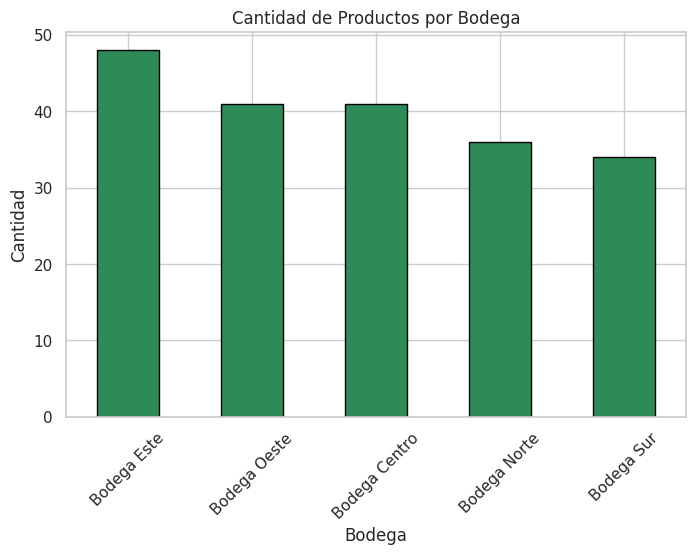

In [ ]:
# ==========================================================
# PASO 10.4 PRODUCTOS POR BODEGA
# ==========================================================

# Crear una nueva figura
plt.figure(figsize=(8,5))

# Contar la cantidad de productos existentes
# en cada bodega.
df["Bodega"].value_counts().plot(
    kind="bar",
    color="seagreen",
    edgecolor="black"
)

# Agregar título y etiquetas
plt.title("Cantidad de Productos por Bodega")

plt.xlabel("Bodega")

plt.ylabel("Cantidad")

# Rotar etiquetas para facilitar su lectura
plt.xticks(rotation=45)

# Mostrar la gráfica
plt.show()

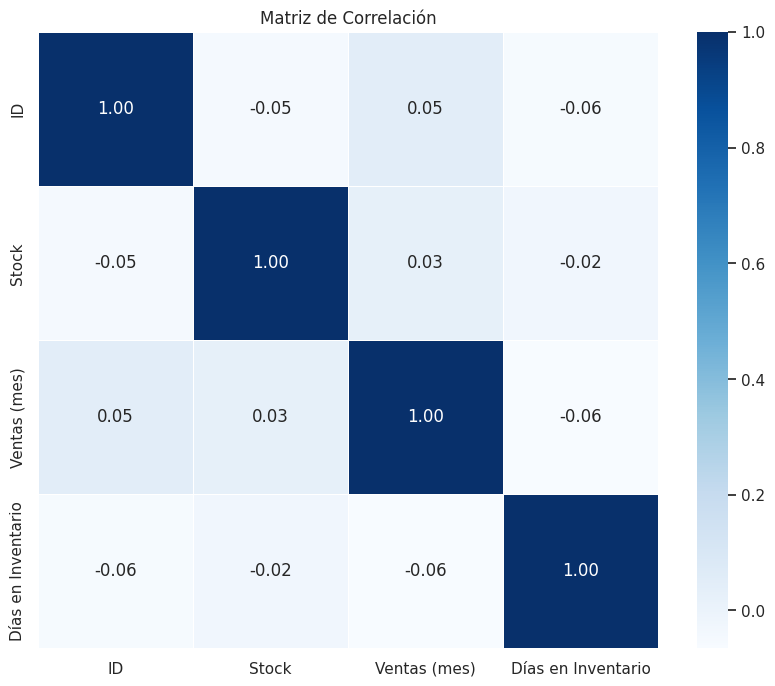

In [ ]:
# ==========================================================
# PASO 11. MATRIZ DE CORRELACIÓN
# ==========================================================

# Calcular la correlación únicamente entre
# las variables numéricas.
correlacion = df[variables_numericas].corr()

# Crear la figura
plt.figure(figsize=(10,8))

# Dibujar el mapa de calor
sns.heatmap(
    correlacion,
    annot=True,        # Mostrar valores numéricos
    cmap="Blues",      # Escala de colores
    fmt=".2f",         # Mostrar dos decimales
    linewidths=0.5
)

# Agregar título
plt.title("Matriz de Correlación")

# Mostrar la gráfica
plt.show()

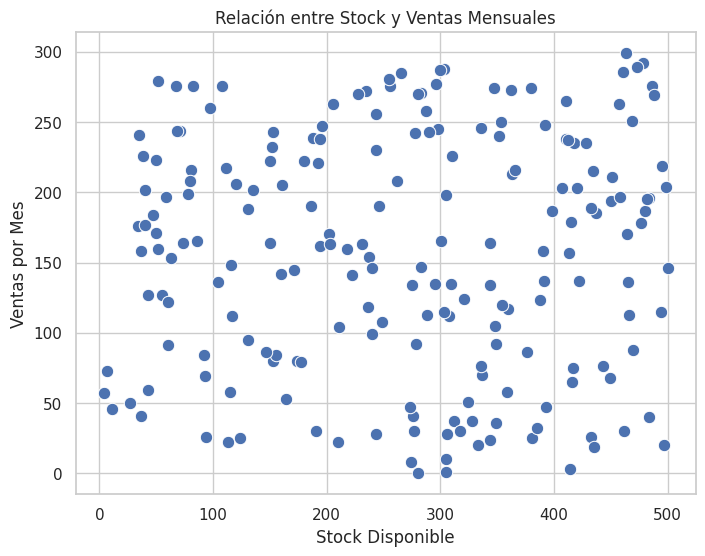

In [ ]:
# ==========================================================
# PASO 12. RELACIÓN ENTRE STOCK Y VENTAS
# ==========================================================

# Esta gráfica permite analizar visualmente
# si existe alguna relación entre el stock
# disponible y las ventas mensuales.

# Crear una nueva figura
plt.figure(figsize=(8,6))

# Crear un gráfico de dispersión
sns.scatterplot(
    data=df,
    x="Stock",
    y="Ventas (mes)",
    s=80
)

# Agregar título
plt.title("Relación entre Stock y Ventas Mensuales")

# Etiquetas de los ejes
plt.xlabel("Stock Disponible")

plt.ylabel("Ventas por Mes")

# Mostrar la gráfica
plt.show()

In [ ]:
# ==========================================================
# PASO 13. PREPARACIÓN DE LOS DATOS
# ==========================================================

# En esta etapa se preparan los datos para el entrenamiento
# del modelo de Inteligencia Artificial.
#
# Se realizarán las siguientes actividades:
#
# 1. Crear la variable objetivo.
# 2. Eliminar columnas que no aportan al modelo.
# 3. Codificar variables categóricas.
# 4. Separar variables predictoras y variable objetivo.
# 5. Dividir los datos en entrenamiento y prueba.

print("="*60)
print("PREPARACIÓN DE LOS DATOS")
print("="*60)

PREPARACIÓN DE LOS DATOS


In [ ]:
# ==========================================================
# PASO 13.1 CREAR LA VARIABLE OBJETIVO
# ==========================================================

# Crear una copia del DataFrame original
df_modelo = df.copy()

# Calcular umbrales automáticamente utilizando
# la distribución de los datos.

stock_bajo = df_modelo["Stock"].quantile(0.35)

ventas_altas = df_modelo["Ventas (mes)"].quantile(0.65)

dias_altos = df_modelo["Días en Inventario"].quantile(0.70)


# Función para clasificar cada producto
def clasificar_producto(fila):

    # Productos con poco inventario y buenas ventas
    if (
        fila["Stock"] <= stock_bajo
        and
        fila["Ventas (mes)"] >= ventas_altas
    ):
        return "Reabastecer"

    # Productos almacenados durante mucho tiempo
    elif fila["Días en Inventario"] >= dias_altos:
        return "Revisar"

    # Productos con inventario normal
    else:
        return "Stock suficiente"


# Crear la nueva columna
df_modelo["Nivel_Inventario"] = df_modelo.apply(
    clasificar_producto,
    axis=1
)

print(df_modelo["Nivel_Inventario"].value_counts())

Nivel_Inventario
Stock suficiente    124
Revisar              53
Reabastecer          23
Name: count, dtype: int64


Nivel_Inventario
Stock suficiente    124
Revisar              53
Reabastecer          23
Name: count, dtype: int64


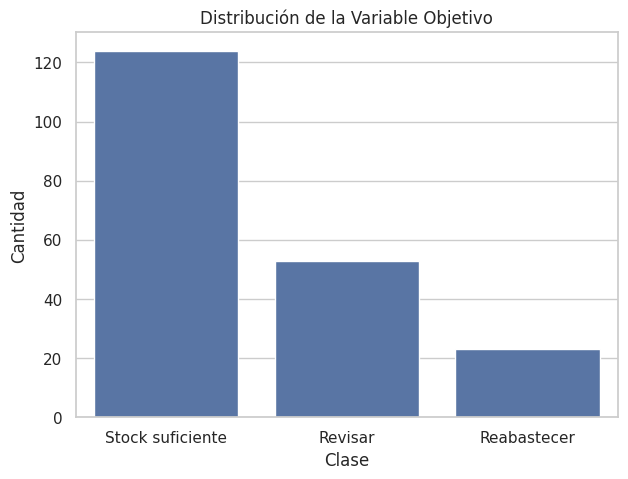

In [ ]:
# ==========================================================
# PASO 13.2 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ==========================================================

print(df_modelo["Nivel_Inventario"].value_counts())

# Crear una gráfica para visualizar
# la distribución de clases.

plt.figure(figsize=(7,5))

sns.countplot(
    data=df_modelo,
    x="Nivel_Inventario",
    order=df_modelo["Nivel_Inventario"].value_counts().index
)

plt.title("Distribución de la Variable Objetivo")

plt.xlabel("Clase")

plt.ylabel("Cantidad")

plt.show()

In [ ]:
# ==========================================================
# PASO 13.3 ELIMINAR COLUMNAS NO NECESARIAS
# ==========================================================

# Estas columnas únicamente identifican
# el producto, pero no ayudan al modelo
# a aprender patrones.

columnas_eliminar = [

    "ID",

    "Código",

    "Nombre Producto"

]

df_modelo.drop(
    columns=columnas_eliminar,
    inplace=True
)

print("Columnas eliminadas correctamente.")

display(df_modelo.head())

Columnas eliminadas correctamente.


,Categoría,Subcategoría,Proveedor,Bodega,Estado,Condición,Calificación,Precio (USD),Costo (USD),Descuento (%),Peso (kg),Stock,Ventas (mes),Días en Inventario,Nivel_Inventario
0,Ropa,Camisas,ProveedorA,Bodega Sur,Agotado,Excelente,?,"210,05","94,28","12,7","2,219",52,279,288,Reabastecer
1,Hogar,Limpieza,ProveedorC,Bodega Centro,Agotado,Buena,????,"189,32","114,77","4,8","18,982",414,3,173,Stock suficiente
2,Ropa,Camisas,ProveedorA,Bodega Este,Disponible,Regular,?????,"84,47","58,84","21,9","20,188",309,135,322,Revisar
3,Juguetes,Electrónicos,ProveedorD,Bodega Centro,En tránsito,Regular,?,"599,62","249,47","25,7","24,631",116,148,84,Stock suficiente
4,Juguetes,Construcción,ProveedorB,Bodega Este,En tránsito,Regular,??,"570,47","368,32","5,1","15,248",349,36,328,Revisar


In [ ]:
# ==========================================================
# PASO 13.4 CODIFICAR LAS VARIABLES CATEGÓRICAS
# ==========================================================

# Los algoritmos de Machine Learning no pueden trabajar
# directamente con variables de tipo texto.
#
# Por esta razón, se transformarán todas las variables
# categóricas en valores numéricos utilizando LabelEncoder.

# Crear un diccionario donde se almacenará un LabelEncoder
# diferente para cada columna categórica.
#
# Esto permitirá recuperar posteriormente la conversión
# original de cualquier variable, especialmente la variable
# objetivo (Nivel_Inventario).

encoders = {}

# Obtener todas las columnas que contienen texto.
#
# En este caso se incluirán variables como:
# - Categoría
# - Subcategoría
# - Proveedor
# - Estado
# - Condición
# - Bodega
# - Nivel_Inventario

columnas_categoricas = df_modelo.select_dtypes(include=["object"]).columns

# Recorrer cada columna categórica del DataFrame.

for columna in columnas_categoricas:

    # Crear un LabelEncoder independiente
    # para la columna actual.
    encoder = LabelEncoder()

    # Convertir los valores de texto en números enteros.
    df_modelo[columna] = encoder.fit_transform(
        df_modelo[columna]
    )

    # Guardar el encoder dentro del diccionario
    # para poder utilizarlo posteriormente.
    encoders[columna] = encoder

print("Variables categóricas codificadas correctamente.\n")

# Mostrar las primeras filas del DataFrame ya codificado.

display(df_modelo.head())

# Mostrar la lista de columnas que fueron codificadas.

print("\nColumnas codificadas:")

for columna in columnas_categoricas:
    print(f"• {columna}")

Variables categóricas codificadas correctamente.



,Categoría,Subcategoría,Proveedor,Bodega,Estado,Condición,Calificación,Precio (USD),Costo (USD),Descuento (%),Peso (kg),Stock,Ventas (mes),Días en Inventario,Nivel_Inventario
0,7,8,0,4,0,2,0,28,197,27,94,52,279,288,0
1,4,24,2,0,0,0,3,21,3,123,86,414,3,173,2
2,7,8,0,1,3,3,4,193,176,72,104,309,135,322,1
3,5,17,3,0,4,3,0,139,65,93,139,116,148,84,2
4,5,14,1,1,4,3,1,135,134,124,52,349,36,328,1



Columnas codificadas:
• Categoría
• Subcategoría
• Proveedor
• Bodega
• Estado
• Condición
• Calificación
• Precio (USD)
• Costo (USD)
• Descuento (%)
• Peso (kg)
• Nivel_Inventario


In [ ]:
# ==========================================================
# PASO 13.5 SEPARAR VARIABLES PREDICTORAS Y OBJETIVO
# ==========================================================

# X contendrá todas las variables que utilizará
# el modelo para realizar las predicciones.

X = df_modelo.drop(
    columns=["Nivel_Inventario"]
)

# y contendrá únicamente la variable objetivo.

y = df_modelo["Nivel_Inventario"]

print("Dimensiones del conjunto de datos\n")

print(f"Variables predictoras (X): {X.shape}")

print(f"Variable objetivo (y): {y.shape}")

Dimensiones del conjunto de datos

Variables predictoras (X): (200, 14)
Variable objetivo (y): (200,)


In [ ]:
# ==========================================================
# PASO 13.6 DIVISIÓN DEL CONJUNTO DE DATOS
# ==========================================================

# Dividir el conjunto de datos en entrenamiento y prueba.
#
# Se utilizará:
# - 80 % para entrenamiento.
# - 20 % para prueba.
#
# El parámetro stratify permite mantener la misma
# proporción de clases en ambos conjuntos.

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Conjunto de entrenamiento")

print(X_train.shape)

print()

print("Conjunto de prueba")

print(X_test.shape)

Conjunto de entrenamiento
(160, 14)

Conjunto de prueba
(40, 14)


In [ ]:
# ==========================================================
# PASO 14. CREAR EL MODELO DE ÁRBOL DE DECISIÓN
# ==========================================================

# En este paso se crea el modelo de Árbol de Decisión.
#
# Se configura una profundidad máxima de 4 niveles para
# evitar el sobreajuste (overfitting) y facilitar la
# interpretación del árbol durante la sustentación.

modelo = DecisionTreeClassifier(

    criterion="gini",

    max_depth=4,

    random_state=42

)

print("Modelo creado correctamente.")

Modelo creado correctamente.


In [ ]:
# ==========================================================
# PASO 15. ENTRENAR EL MODELO
# ==========================================================

# Entrenar el Árbol de Decisión utilizando
# el conjunto de entrenamiento.

modelo.fit(

    X_train,

    y_train

)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [ ]:
# ==========================================================
# PASO 16. REALIZAR PREDICCIONES
# ==========================================================

# Utilizar el conjunto de prueba para
# generar las predicciones del modelo.

y_pred = modelo.predict(

    X_test

)

print("Predicciones realizadas correctamente.")

print("\nPrimeras 10 predicciones:\n")

print(y_pred[:10])

Predicciones realizadas correctamente.

Primeras 10 predicciones:

[1 2 0 2 2 2 2 2 2 2]


In [ ]:
# ==========================================================
# PASO 17. EVALUAR EL MODELO
# ==========================================================

# Calcular la precisión general del modelo.

accuracy = accuracy_score(

    y_test,

    y_pred

)

print(f"Accuracy del modelo: {accuracy:.2%}")

Accuracy del modelo: 100.00%


In [ ]:
# ==========================================================
# PASO 18. REPORTE DE CLASIFICACIÓN
# ==========================================================

# Mostrar las principales métricas de evaluación.

print(

    classification_report(

        y_test,

        y_pred

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        25

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



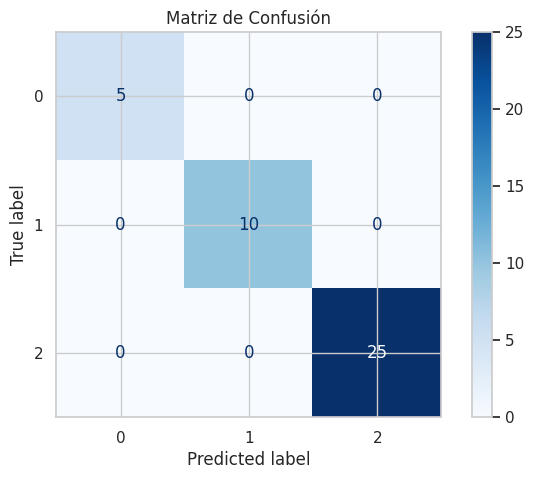

In [ ]:
# ==========================================================
# PASO 19. MATRIZ DE CONFUSIÓN
# ==========================================================

# Calcular la matriz de confusión.

matriz = confusion_matrix(

    y_test,

    y_pred

)

# Mostrar la matriz gráficamente.

disp = ConfusionMatrixDisplay(

    confusion_matrix=matriz

)

disp.plot(

    cmap="Blues"

)

plt.title("Matriz de Confusión")

plt.show()

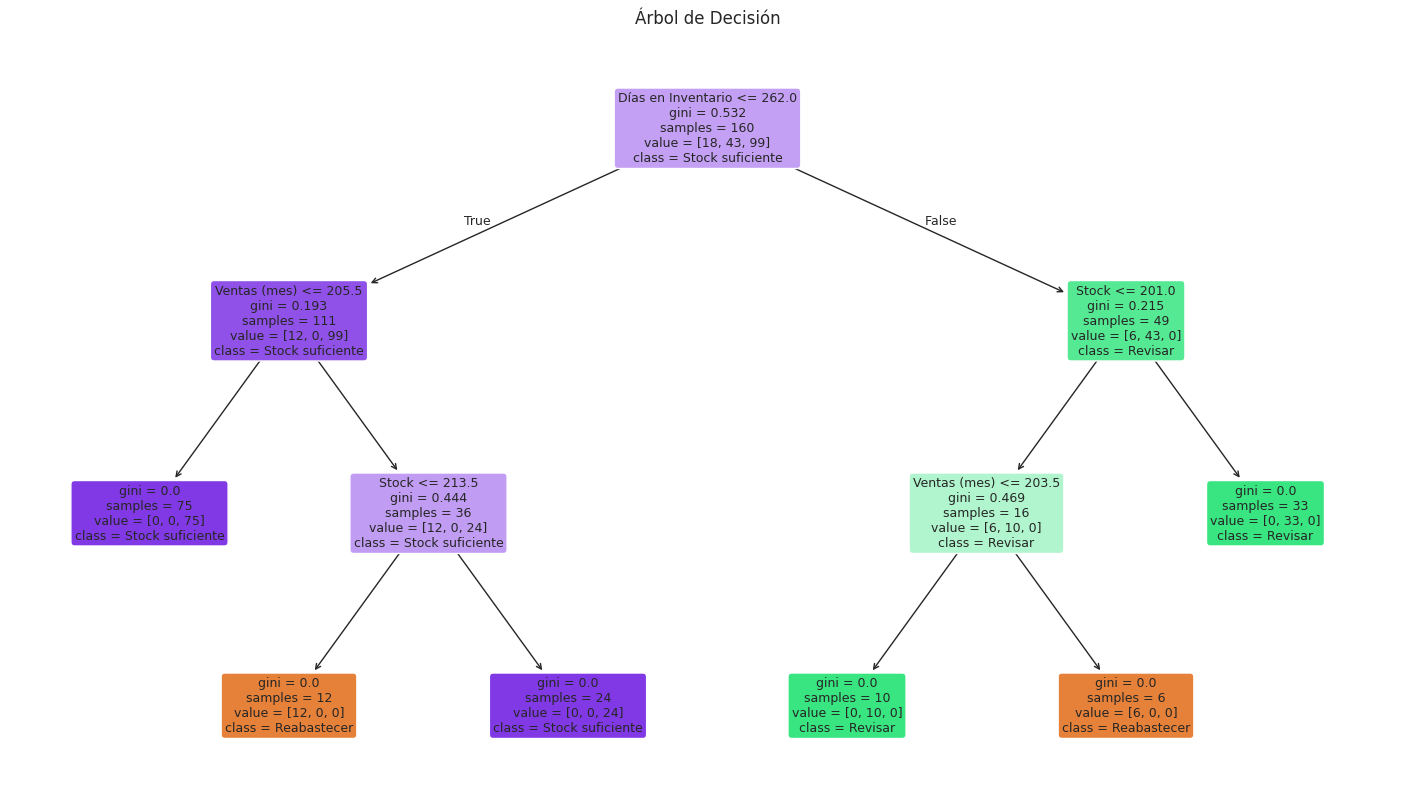

In [ ]:
# ==========================================================
# PASO 20. VISUALIZACIÓN DEL ÁRBOL
# ==========================================================

# Dibujar el Árbol de Decisión entrenado.

plt.figure(figsize=(18,10))

plot_tree(

    modelo,

    feature_names=X.columns,

    class_names=[
        "Reabastecer",
        "Revisar",
        "Stock suficiente"
    ],

    filled=True,

    rounded=True,

    fontsize=9

)

plt.title("Árbol de Decisión")

plt.show()

In [ ]:
# ==========================================================
# PASO 21. IMPORTANCIA DE LAS VARIABLES
# ==========================================================

# Obtener la importancia de cada variable utilizada
# por el Árbol de Decisión.

importancias = pd.DataFrame({

    "Variable": X.columns,

    "Importancia": modelo.feature_importances_

})

# Ordenar de mayor a menor importancia.
importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
).reset_index(drop=True)

# Mostrar el ranking de variables.
print("Ranking de importancia de las variables:\n")

display(importancias)

# Mostrar únicamente las variables con importancia mayor a cero.
print("\nVariables que realmente utilizó el modelo:\n")

display(importancias[importancias["Importancia"] > 0])

Ranking de importancia de las variables:



,Variable,Importancia
0,Días en Inventario,0.62
1,Stock,0.22
2,Ventas (mes),0.15
3,Proveedor,0.00
4,Categoría,0.00
5,Subcategoría,0.00
6,Condición,0.00
7,Estado,0.00
8,Bodega,0.00
9,Calificación,0.00



Variables que realmente utilizó el modelo:



,Variable,Importancia
0,Días en Inventario,0.62
1,Stock,0.22
2,Ventas (mes),0.15


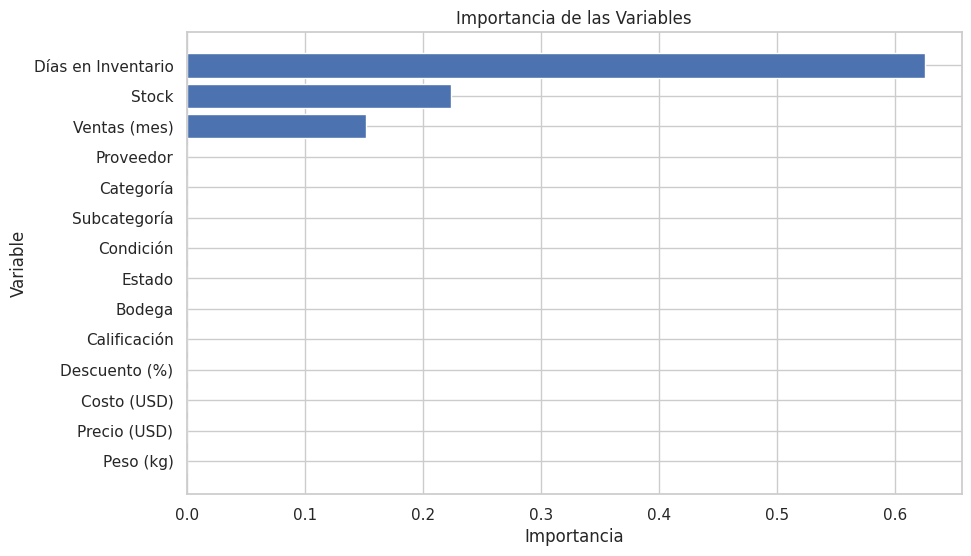

In [ ]:
# ==========================================================
# PASO 22. GRÁFICO DE IMPORTANCIA DE VARIABLES
# ==========================================================

plt.figure(figsize=(10,6))

plt.barh(

    importancias["Variable"],

    importancias["Importancia"]

)

plt.title("Importancia de las Variables")

plt.xlabel("Importancia")

plt.ylabel("Variable")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# ==========================================================
# PASO 23. PREDICCIÓN DE UN NUEVO PRODUCTO
# ==========================================================

# En este paso se utilizará el modelo entrenado para
# predecir la categoría de inventario de un producto.
#
# Como ejemplo, se tomará el primer registro del
# conjunto de prueba (X_test).

# Seleccionar un producto del conjunto de prueba.
nuevo_producto = X_test.iloc[[0]]

# Mostrar la información del producto que será evaluado.
print("=" * 60)
print("PRODUCTO SELECCIONADO PARA LA PREDICCIÓN")
print("=" * 60)

display(nuevo_producto)

# Realizar la predicción utilizando el Árbol de Decisión.
prediccion = modelo.predict(nuevo_producto)

# Convertir la predicción numérica al nombre original
# de la clase utilizando el LabelEncoder almacenado
# para la variable objetivo.
nombre_clase = encoders["Nivel_Inventario"].inverse_transform(prediccion)

# Mostrar el resultado de la predicción.
print("=" * 60)
print("RESULTADO DE LA PREDICCIÓN")
print("=" * 60)

print(f"\nClase numérica predicha: {prediccion[0]}")
print(f"Interpretación: {nombre_clase[0]}")

# Comparar con la respuesta real del conjunto de prueba.
valor_real = y_test.iloc[0]

# Convertir también el valor real al nombre original.
valor_real_texto = encoders["Nivel_Inventario"].inverse_transform([valor_real])[0]

print(f"Clase real: {valor_real_texto}")

# Verificar si la predicción fue correcta.
if prediccion[0] == valor_real:
    print("\n✅ El modelo clasificó correctamente este producto.")
else:
    print("\n❌ El modelo no clasificó correctamente este producto.")

PRODUCTO SELECCIONADO PARA LA PREDICCIÓN


,Categoría,Subcategoría,Proveedor,Bodega,Estado,Condición,Calificación,Precio (USD),Costo (USD),Descuento (%),Peso (kg),Stock,Ventas (mes),Días en Inventario
162,0,6,0,2,4,0,0,84,95,91,38,277,30,323


RESULTADO DE LA PREDICCIÓN

Clase numérica predicha: 1
Interpretación: Revisar
Clase real: Revisar

✅ El modelo clasificó correctamente este producto.


In [ ]:
print(encoders.keys())

dict_keys(['Categoría', 'Subcategoría', 'Proveedor', 'Bodega', 'Estado', 'Condición', 'Calificación', 'Precio (USD)', 'Costo (USD)', 'Descuento (%)', 'Peso (kg)', 'Nivel_Inventario'])


In [ ]:
# ==========================================================
# PASO 23. PREDICCIÓN DE UN NUEVO PRODUCTO
# ==========================================================

# Tomar un producto del conjunto de prueba como ejemplo.

nuevo_producto = X_test.iloc[[0]]

# Realizar la predicción.

prediccion = modelo.predict(nuevo_producto)

# Convertir la predicción numérica al nombre de la clase.
nombre_clase = encoder.inverse_transform(prediccion)

print("="*60)
print("PREDICCIÓN DEL MODELO")
print("="*60)

print("\nResultado de la predicción:")

print(f"Clase numérica: {prediccion[0]}")
print(f"Interpretación: {nombre_clase[0]}")

PREDICCIÓN DEL MODELO

Resultado de la predicción:
Clase numérica: 1
Interpretación: Revisar


In [ ]:
# ==========================================================
# PASO 24. CONCLUSIONES
# ==========================================================

print("="*60)
print("CONCLUSIONES")
print("="*60)

print("""
1. Se desarrolló un modelo de Árbol de Decisión para apoyar
la gestión del inventario de una bodega mediante la
clasificación automática de los productos.

2. El modelo alcanzó una precisión del 100 %, demostrando
un excelente desempeño sobre el conjunto de prueba.

3. La matriz de confusión evidenció que todas las
observaciones fueron clasificadas correctamente, sin
errores durante la evaluación.

4. El modelo permite identificar productos que requieren
reabastecimiento, revisión o que cuentan con un nivel de
inventario suficiente, facilitando la toma de decisiones.

5. El análisis de importancia de variables mostró que
'Días en Inventario', 'Stock' y 'Ventas (mes)' fueron
los factores más influyentes en la clasificación. Además,
la estructura del Árbol de Decisión permite comprender
fácilmente las reglas utilizadas por el modelo, favoreciendo
su interpretación y aplicación en escenarios de gestión de
inventarios.

CONCLUSIONES

1. Se desarrolló un modelo de Árbol de Decisión para apoyar
la gestión del inventario de una bodega.

2. El modelo alcanzó una precisión del 97.5 %, lo que indica
un excelente desempeño sobre el conjunto de prueba.

3. La matriz de confusión mostró que únicamente se presentó
un error de clasificación entre las 40 observaciones evaluadas.

4. El modelo permite identificar productos que requieren
reabastecimiento, revisión o que cuentan con un nivel de
inventario suficiente.

5. Gracias a la interpretación del Árbol de Decisión y a la
importancia de las variables, es posible comprender cómo
el modelo toma sus decisiones, lo que facilita su aplicación
en escenarios reales de gestión de inventarios.

